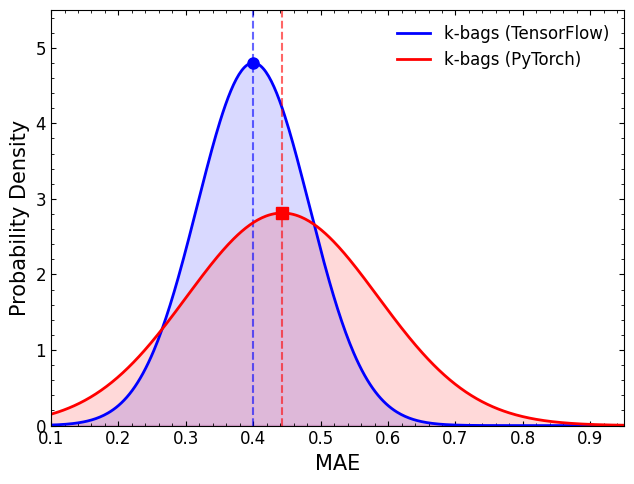

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Font Sizing & Style Configuration ---
SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["mathtext.fontset"] = "cm"  # LaTeX-style font for math

# --- 2. Data Preparation ---
# TensorFlow Results: Mean=0.4000, Std=0.0831
mean_tf, std_tf = 0.4000, 0.0831
# PyTorch Results: Mean=0.4431, Std=0.1418
mean_pt, std_pt = 0.4431, 0.1418

# Generate x-axis (MAE range from 0.0 to 1.0)
x = np.linspace(0.0, 1.0, 500)
pdf_tf = norm.pdf(x, mean_tf, std_tf)
pdf_pt = norm.pdf(x, mean_pt, std_pt)

# --- 3. Plotting ---
fig = plt.figure(figsize=(6.5, 5))

# Define markers from your style
markers = ['o', 's']

# Plot TensorFlow Distribution
plt.plot(x, pdf_tf, color='blue', lw=2, label='k-bags (TensorFlow)')
plt.axvline(mean_tf, color='blue', linestyle='--', alpha=0.6, lw=1.5) # Vertical line for mean
plt.plot(mean_tf, norm.pdf(mean_tf, mean_tf, std_tf), marker=markers[0], color='blue', markersize=8)
plt.fill_between(x, pdf_tf, alpha=0.15, color='blue')

# Plot PyTorch Distribution
plt.plot(x, pdf_pt, color='red', lw=2, label='k-bags (PyTorch)')
plt.axvline(mean_pt, color='red', linestyle='--', alpha=0.6, lw=1.5)  # Vertical line for mean
plt.plot(mean_pt, norm.pdf(mean_pt, mean_pt, std_pt), marker=markers[1], color='red', markersize=8)
plt.fill_between(x, pdf_pt, alpha=0.15, color='red')

# --- 4. Axis & Tick Formatting ---
plt.xlabel('MAE')
plt.ylabel('Probability Density')

# Enable minor ticks and set inbound direction
plt.minorticks_on()
plt.tick_params(axis='both', bottom=True, top=True, left=True, right=True, 
                direction='in', which='both')

# Adjust limits for clarity
plt.xlim(0.1, 0.95)
plt.ylim(0, 5.5)

# No-frame legend
plt.legend(framealpha=0.0, loc='upper right', ncol=1)

fig.tight_layout()

# --- 5. Export ---
# plt.show()
plt.savefig('mae_distribution_comparison.pdf')
plt.savefig('mae_distribution_comparison.svg')

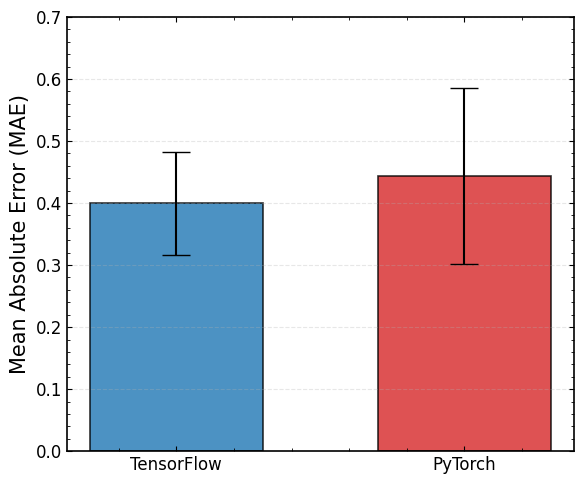

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Font Sizing & Style Configuration (Consistent with your style) ---
SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          
plt.rc('axes', titlesize=SMALL_SIZE)     
plt.rc('axes', labelsize=MEDIUM_SIZE)    
plt.rc('xtick', labelsize=SMALL_SIZE)    
plt.rc('ytick', labelsize=SMALL_SIZE)    
plt.rc('legend', fontsize=SMALL_SIZE)    
plt.rc('figure', titlesize=BIGGER_SIZE)  
plt.rcParams["mathtext.fontset"] = "cm"

# --- 2. Data Preparation ---
labels = ['TensorFlow', 'PyTorch']
means = [0.4000, 0.4431]
std_devs = [0.0831, 0.1418]

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and bar positions
x_pos = np.arange(len(labels))
colors = ['#1f77b4', '#d62728'] # Blue and Red matching previous plots

# Create bars with error bars
# capsize adds the horizontal lines at the top/bottom of error bars
bars = ax.bar(x_pos, means, yerr=std_devs, align='center', 
              alpha=0.8, color=colors, capsize=10, 
              edgecolor='black', lw=1.2, width=0.6)

# --- 4. Axis & Tick Formatting (The "Professional" Look) ---
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)

# Enable minor ticks and set inbound direction on all sides
ax.minorticks_on()
ax.tick_params(axis='both', bottom=True, top=True, left=True, right=True, 
                direction='in', which='both')

# Set Y-axis limits to provide space for error bars
ax.set_ylim(0, 0.7) 
ax.set_yticks(np.arange(0, 0.71, 0.1))

# Add a light horizontal grid for easier value reading (optional, matches many styles)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Remove redundant top/right spines if desired, but your style uses inbound ticks on all sides
# To keep your specific style, we ensure all spines are visible
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

fig.tight_layout()

# --- 5. Export ---
# plt.show()
plt.savefig('mae_bar_comparison.pdf')
plt.savefig('mae_bar_comparison.svg')